# Моделирование распространения заболевания с помощью агентного моделирования

Этот Jupyter Notebook содержит улучшенную версию моделирования распространения заболевания с использованием агентного подхода. В данной модели каждый человек (агент) имеет свои характеристики, такие как положение, скорость, состояние здоровья (здоров, инфицирован, иммунен) и критический уровень здоровья.

Модель позволяет исследовать различные сценарии распространения инфекции, включая влияние карантина и вакцинации, а также изменение плотности населения. Визуализация результатов осуществляется с помощью графиков, демонстрирующих динамику численности здоровых, инфицированных и иммунных агентов с течением времени.

## Содержание:
1.  **Настройка среды**: Установка необходимых библиотек.
2.  **Базовая модель**: Три симуляции с различными начальными состояниями случайных чисел для демонстрации стохастичности процесса.
3.  **Моделирование карантина**: Влияние режима 'не выходить из дома' на распространение заболевания.
4.  **Моделирование вакцинации**: Эффект массовой вакцинации на динамику инфекции.
5.  **Моделирование плотности населения**: Распространение вируса в ограниченной области с высокой плотностью агентов.

In [1]:
# Установка необходимых библиотек: numpy для числовых операций и matplotlib для построения графиков.
!pip install numpy matplotlib

## 1. Базовая модель: Три симуляции с различными случайными начальными состояниями

В этом разделе мы проводим три симуляции распространения заболевания. Каждая симуляция использует 500 агентов и длится 250 итераций. Основное отличие между симуляциями заключается в использовании различных "seed" для генератора случайных чисел, что демонстрирует стохастический характер моделирования. Графики показывают изменения количества здоровых, инфицированных и иммунных людей с течением времени для каждого случая.

### Логика работы кода:
Код разбит на отдельные блоки для улучшения читаемости и модульности:
-   **Параметры модели**: Определены основные константы, управляющие симуляцией.
-   **Класс `Person`**: Описывает поведение и характеристики каждого индивидуального агента.
-   **Функции моделирования**: Реализуют логику движения, взаимодействия, изменения здоровья и сбора данных.
-   **Функции визуализации**: Отвечают за построение графиков.
-   **Основной цикл симуляции**: Запускает симуляции с различными начальными состояниями.

### 1.1. Константы модели

Этот блок определяет глобальные параметры, которые влияют на поведение всех агентов и на симуляцию в целом.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

SPACES = 100        # Размер пространства модели (ширина и высота)
VELOCOEF = 5        # Коэффициент скорости движения агентов
ASCOEF = 0.1        # Коэффициент ускорения агентов
HEALTH_MID = 100    # Средний начальный уровень здоровья
IMUNOPOWER = 0.8    # Вероятность получения иммунитета после контакта с инфицированным
INI_ILL = 5         # Начальное количество инфицированных агентов
POPULATION = 500    # Общее количество агентов в симуляции
R_COMM = 5          # Радиус взаимодействия для столкновений и передачи болезни

# Глобальные переменные для отслеживания состояния (будут использоваться в функциях)
Inf_count = 0       # Текущее количество инфицированных (пересчитывается в Iterate)
CollideCount = 0    # Счетчик столкновений (не используется для графиков, можно убрать или использовать для статистики)
XLim = SPACES       # Предел по X для движения агентов
YLim = SPACES       # Предел по Y для движения агентов


### 1.2. Класс `Person`

Этот класс определяет свойства и поведение каждого индивидуального агента в симуляции.
-   **`__init__`**: Инициализация агента со случайными начальными координатами, скоростью, здоровьем и статусом (жив, не инфицирован, не иммунен).
-   **`Move`**: Обновляет позицию агента, имитируя движение и отскоки от границ мира.
-   **`LowerHealth`**: Уменьшает здоровье инфицированных агентов; если здоровье достигает нуля, агент умирает.
-   **`Cured`**: Обрабатывает процесс выздоровления и приобретения иммунитета.
-   **`Distance`**: Вычисляет расстояние до другого агента.
-   **`Collide`**: Моделирует столкновение между агентами, влияя на их скорости и потенциально передавая инфекцию.

In [3]:
class Person:
    def __init__(self):
        self.x = np.random.rand(2) * (SPACES - 1)  # Координаты x-y
        self.v = np.random.rand(2) * VELOCOEF + 1  # Скорость x-y
        self.a = np.zeros(2) + ASCOEF             # Ускорение x-y
        self.alive = True
        self.immune = False
        self.infected = False
        self.health = np.random.randint(HEALTH_MID - 30, HEALTH_MID + 30) # Текущий уровень здоровья
        self.bottom = np.random.randint(-50, self.health - 30)           # Критический уровень здоровья

    def __str__(self):
        st = ''
        temps = vars(self)
        for item in temps:  st += f'{item}: {temps[item]}\n'
        return st

    def Move(self, V, H, dt=0.1):
        # Изменено: dt приведено к единому значению 0.1
        self.x[0] += self.v[0] * dt * np.random.choice([-1, 1]) + 0.5 * self.a[0] * dt * dt
        self.x[1] += self.v[1] * dt + self.a[1] * dt * dt

        if self.x[0] < 0:
            self.x[0] *= -1
            self.v[0] *= -1
        if self.x[0] > H:
            self.x[0] = H - 1
            self.v[0] *= -1
        if self.x[1] < 0:
            self.x[1] *= -1
            self.v[1] *= -1
        if self.x[1] > V:
            self.x[1] = V - 1
            self.v[1] *= -1

    def LowerHealth(self):
        if self.infected and self.health > self.bottom:
            self.health -= 1
        self.alive = (self.health > 0)

    def Cured(self):
        global Inf_count
        if self.infected and self.health <= self.bottom:
            self.infected = False
            Inf_count -= 1
            self.immune = True
            self.bottom -= 5
        if self.immune:
            self.health += np.random.choice([1, 0])

    def Distance(self, you):
        return np.linalg.norm(self.x - you.x)

    def Collide(self, you):
        ypart = you.x[1] - self.x[1]
        xpart = you.x[0] - self.x[0]
        alpha = np.arctan2(ypart, xpart)
        R = np.array(((np.cos(-alpha), -np.sin(-alpha)),
                      (np.sin(-alpha), np.cos(-alpha))))
        vrot = R.dot(self.v)
        wrot = vrot * np.array((1, -1))
        R = np.array(((np.cos(alpha), -np.sin(alpha)),
                      (np.sin(alpha), np.cos(alpha))))
        w = R.dot(wrot)
        self.v = w + 0.05

        if you.infected and not self.immune and self.alive:
            if np.random.rand() > IMUNOPOWER:
                self.infected = True
                self.immune = False


### 1.3. Функции моделирования

Эти функции управляют ходом симуляции, включая итерацию по шагам, создание начального мира и сбор данных.
-   **`Iterate`**: Выполняет один шаг симуляции, обрабатывая движение, здоровье и взаимодействия всех агентов.
-   **`CreateWorld`**: Инициализирует мир, создавая заданное количество агентов и устанавливая некоторых из них как инфицированных.
-   **`CollectData`**: Собирает статистические данные о количестве здоровых, инфицированных и иммунных агентов на каждом шаге.

In [4]:
def Iterate():
    global R_COMM, CollideCount, XLim, YLim, people, Inf_count
    Inf_count = 0  # Сбрасываем счетчик инфицированных в начале каждой итерации

    for i, me in enumerate(people):
        if me.alive:
            me.Move(YLim, XLim, dt=0.1) # Изменено: dt приведено к единому значению 0.1
            me.LowerHealth()
            me.Cured()

            for j in range(i + 1, len(people)): # Оптимизация: проверяем только с теми, кто еще не был проверен в этой паре
                you = people[j]
                if you.alive and me != you:
                    if me.Distance(you) < R_COMM:
                        CollideCount += 1
                        me.Collide(you)
                        you.Collide(me)
        if me.infected and me.alive:
            Inf_count += 1

def CreateWorld(NPeople=100):
    people = [Person() for _ in range(NPeople)]
    for p in people[:INI_ILL]:
        p.infected = True
    return people

def CollectData(step):
    global LivInfIm, people
    healthy = 0
    infected = 0
    immune = 0

    for person in people:
        if person.alive:
            if person.infected:
                infected += 1
            elif person.immune:
                immune += 1
            else:
                healthy += 1

    LivInfIm[0, step] = healthy
    LivInfIm[1, step] = infected
    LivInfIm[2, step] = immune


### 1.4. Функции визуализации

Этот блок содержит функцию для построения красивых и информативных графиков, отображающих динамику здоровых, инфицированных и иммунных агентов.

In [5]:
def plotgrafiks(current_seed):
    plt.figure(figsize=(12, 7)) # Увеличенный размер для лучшей видимости
    plt.style.use('seaborn-v0_8-darkgrid') # Применяем стиль для улучшения внешнего вида

    # Цвета линий и стили
    plt.plot(LivInfIm[0], label='Здоровые', color='mediumseagreen', linewidth=2.5)
    plt.plot(LivInfIm[1], label='Инфицированные', color='tomato', linewidth=2.5)
    plt.plot(LivInfIm[2], label='Иммунные', color='cornflowerblue', linewidth=2.5)

    plt.title(f'Моделирование распространения заболевания (Seed: {current_seed})', fontsize=16, fontweight='bold')
    plt.xlabel('Временные шаги', fontsize=12)
    plt.ylabel('Количество людей', fontsize=12)
    plt.legend(fontsize=10, frameon=True, shadow=True, borderpad=1)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.ylim(bottom=0) # Начало оси Y с нуля
    plt.tight_layout() # Автоматическая корректировка параметров графика для плотного расположения
    plt.show()


### 1.5. Основной цикл симуляции (Базовая модель)

Этот блок запускает три симуляции с различными начальными значениями для генератора случайных чисел, демонстрируя изменчивость результатов.

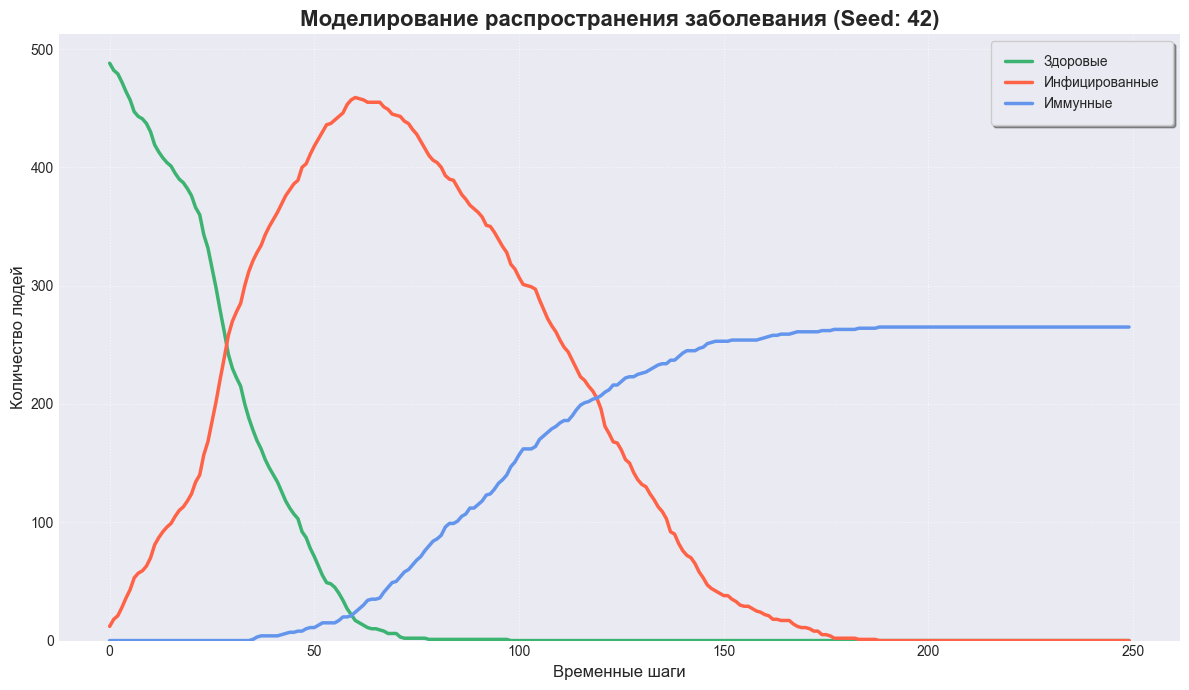

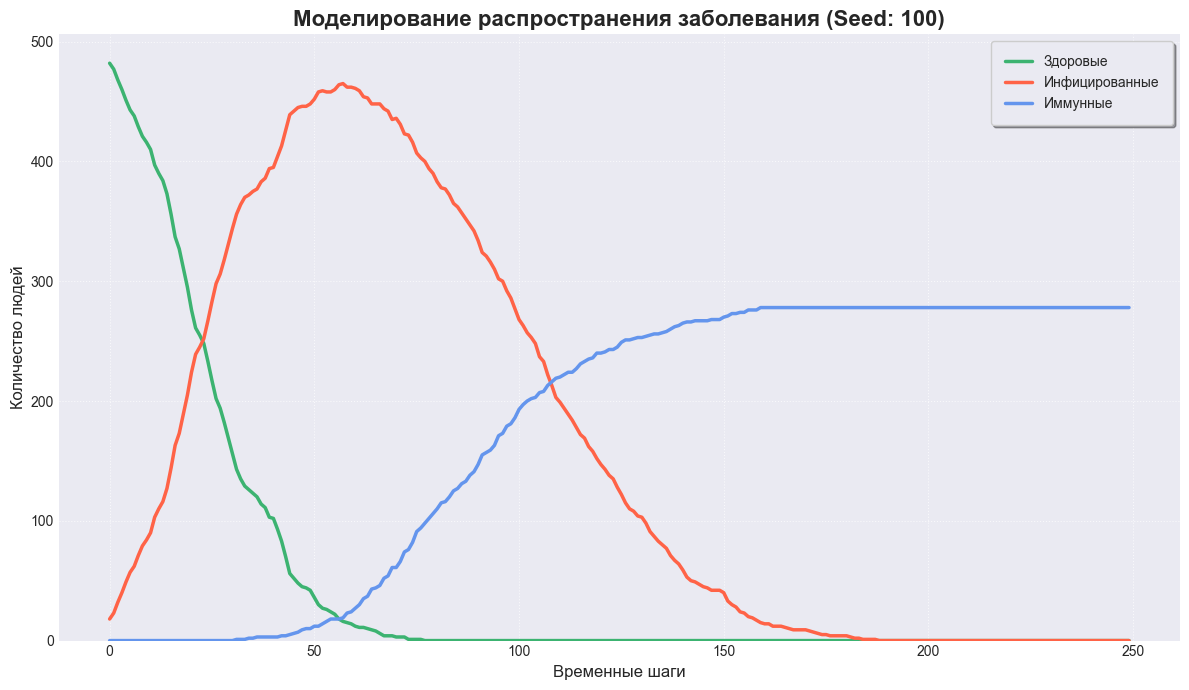

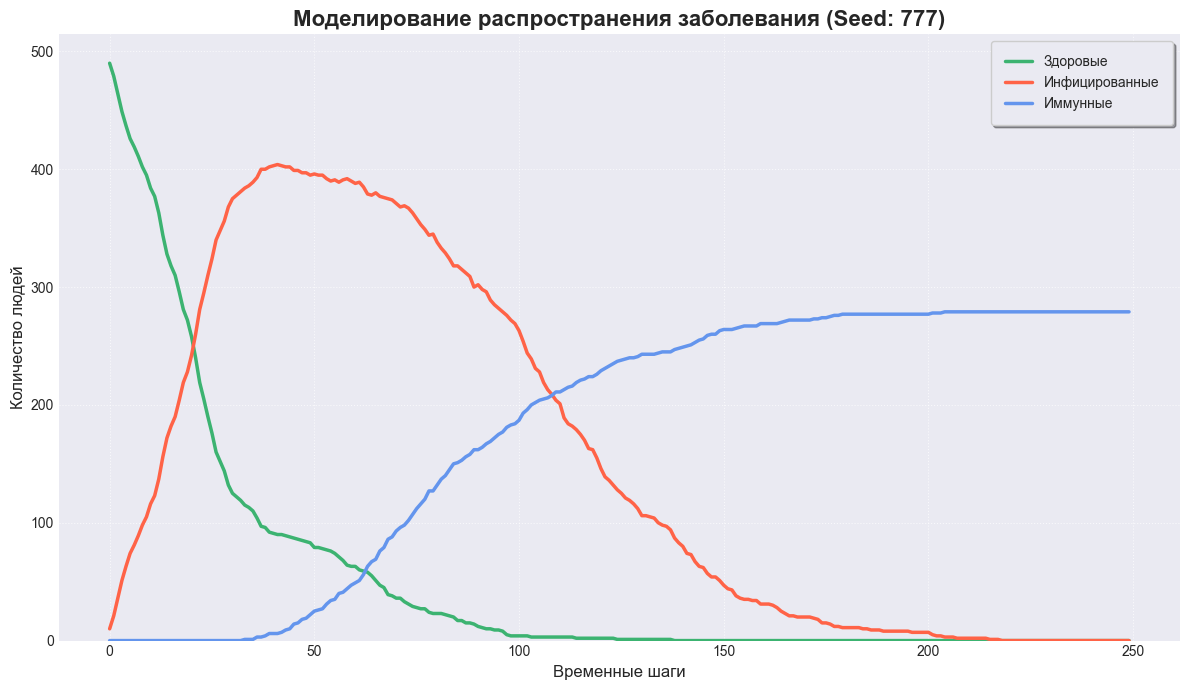

In [6]:
# Список seed'ов для проведения нескольких симуляций
seeds = [42, 100, 777]

for current_seed in seeds:
    np.random.seed(current_seed) # Установка seed для воспроизводимости
    N_ITERS = 250                # Длительность симуляции
    
    people = CreateWorld(POPULATION)
    LivInfIm = np.zeros((3, N_ITERS), dtype=int)

    for step in range(N_ITERS):
        Iterate()
        CollectData(step)
    
    plotgrafiks(current_seed)


## 2. Моделирование режима "не выходить из дома" (карантин)

В этом разделе мы исследуем влияние режима изоляции (карантина) на распространение заболевания. Моделирование проводится для 600 агентов и 300 итераций. Режим "не выходить из дома" вводится на 50-й итерации, при этом скорости всех агентов сохраняются и затем обнуляются. Через 100 итераций (на 150-й итерации) карантин отменяется, и сохраненные скорости восстанавливаются. График результатов показывает, как эти меры влияют на динамику инфекции.

### Логика работы кода:
Код разбит на отдельные блоки для улучшения читаемости и модульности:
-   **Параметры модели**: Обновленные константы для этого сценария.
-   **Класс `Person`**: Используется тот же класс `Person`.
-   **Функции моделирования**: Используются те же функции моделирования.
-   **Функции визуализации**: Добавлена специальная функция для графиков с отметками карантина.
-   **Основной цикл симуляции**: Реализована логика сохранения/восстановления скоростей для карантина.

### 2.1. Константы модели (для сценария с карантином)

В этом сценарии `POPULATION` увеличена, чтобы лучше показать влияние карантина на большую группу.

In [7]:
SPACES = 100
VELOCOEF = 5
ASCOEF = 0.1
HEALTH_MID = 100
IMUNOPOWER = 0.8
INI_ILL = 5
POPULATION = 600   # Увеличена популяция для этого сценария
SEED = 42
R_COMM = 5

Inf_count = 0
CollideCount = 0
XLim = SPACES
YLim = SPACES


### 2.2. Класс `Person` (для сценария с карантином)

Используется тот же класс `Person` без изменений.

In [8]:
class Person:
    def __init__(self):
        self.x = np.random.rand(2) * (SPACES - 1)
        self.v = np.random.rand(2) * VELOCOEF + 1
        self.a = np.zeros(2) + ASCOEF
        self.alive = True
        self.immune = False
        self.infected = False
        self.health = np.random.randint(HEALTH_MID - 30, HEALTH_MID + 30)
        self.bottom = np.random.randint(-50, self.health - 30)

    def __str__(self):
        st = ''
        temps = vars(self)
        for item in temps:  st += f'{item}: {temps[item]}\n'
        return st

    def Move(self, V, H, dt=0.1):
        self.x[0] += self.v[0] * dt * np.random.choice([-1, 1]) + 0.5 * self.a[0] * dt * dt
        self.x[1] += self.v[1] * dt + self.a[1] * dt * dt

        if self.x[0] < 0:
            self.x[0] *= -1
            self.v[0] *= -1
        if self.x[0] > H:
            self.x[0] = H - 1
            self.v[0] *= -1
        if self.x[1] < 0:
            self.x[1] *= -1
            self.v[1] *= -1
        if self.x[1] > V:
            self.x[1] = V - 1
            self.v[1] *= -1

    def LowerHealth(self):
        if self.infected and self.health > self.bottom:
            self.health -= 1
        self.alive = (self.health > 0)

    def Cured(self):
        global Inf_count
        if self.infected and self.health <= self.bottom:
            self.infected = False
            Inf_count -= 1
            self.immune = True
            self.bottom -= 5
        if self.immune:
            self.health += np.random.choice([1, 0])

    def Distance(self, you):
        return np.linalg.norm(self.x - you.x)

    def Collide(self, you):
        ypart = you.x[1] - self.x[1]
        xpart = you.x[0] - self.x[0]
        alpha = np.arctan2(ypart, xpart)
        R = np.array(((np.cos(-alpha), -np.sin(-alpha)),
                      (np.sin(-alpha), np.cos(-alpha))))
        vrot = R.dot(self.v)
        wrot = vrot * np.array((1, -1))
        R = np.array(((np.cos(alpha), -np.sin(alpha)),
                      (np.sin(alpha), np.cos(alpha))))
        w = R.dot(wrot)
        self.v = w + 0.05

        if you.infected and not self.immune and self.alive:
            if np.random.rand() > IMUNOPOWER:
                self.infected = True
                self.immune = False


### 2.3. Функции моделирования (для сценария с карантином)

Эти функции остаются такими же, как и в базовой модели, поскольку логика движения, здоровья и сбора данных универсальна.

In [9]:
def Iterate():
    global R_COMM, CollideCount, XLim, YLim, people, Inf_count
    Inf_count = 0

    for i, me in enumerate(people):
        if me.alive:
            me.Move(YLim, XLim, dt=0.1) # Изменено: dt приведено к единому значению 0.1
            me.LowerHealth()
            me.Cured()

            for j in range(i + 1, len(people)):
                you = people[j]
                if you.alive and me != you:
                    if me.Distance(you) < R_COMM:
                        CollideCount += 1
                        me.Collide(you)
                        you.Collide(me)
        if me.infected and me.alive:
            Inf_count += 1

def CreateWorld(NPeople=100):
    people = [Person() for _ in range(NPeople)]
    for p in people[:INI_ILL]:
        p.infected = True
    return people

def CollectData(step):
    global LivInfIm, people
    healthy = 0
    infected = 0
    immune = 0

    for person in people:
        if person.alive:
            if person.infected:
                infected += 1
            elif person.immune:
                immune += 1
            else:
                healthy += 1

    LivInfIm[0, step] = healthy
    LivInfIm[1, step] = infected
    LivInfIm[2, step] = immune


### 2.4. Функции визуализации (для сценария с карантином)

Эта функция `plotgrafiks_lockdown` специально адаптирована для сценария с карантином, добавляя вертикальные линии на график для обозначения начала и конца периода изоляции.

In [10]:
def plotgrafiks_lockdown():
    plt.figure(figsize=(14, 8)) # Увеличенный размер графика
    plt.style.use('seaborn-v0_8-darkgrid')

    plt.plot(LivInfIm[0], label='Здоровые', color='mediumseagreen', linewidth=2.5)
    plt.plot(LivInfIm[1], label='Инфицированные', color='tomato', linewidth=2.5)
    plt.plot(LivInfIm[2], label='Иммунные', color='cornflowerblue', linewidth=2.5)

    plt.axvline(x=50, color='gray', linestyle='--', linewidth=2, label='Начало карантина (шаг 50)')
    plt.axvline(x=150, color='black', linestyle='--', linewidth=2, label='Окончание карантина (шаг 150)')

    plt.title('Моделирование распространения заболевания с карантином', fontsize=18, fontweight='bold')
    plt.xlabel('Временные шаги', fontsize=14)
    plt.ylabel('Количество людей', fontsize=14)
    plt.legend(fontsize=12, frameon=True, shadow=True, borderpad=1)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()


### 2.5. Основной цикл симуляции (Сценарий с карантином)

Этот блок содержит цикл симуляции, в котором реализована логика введения и отмены карантина путем манипуляции скоростями агентов.

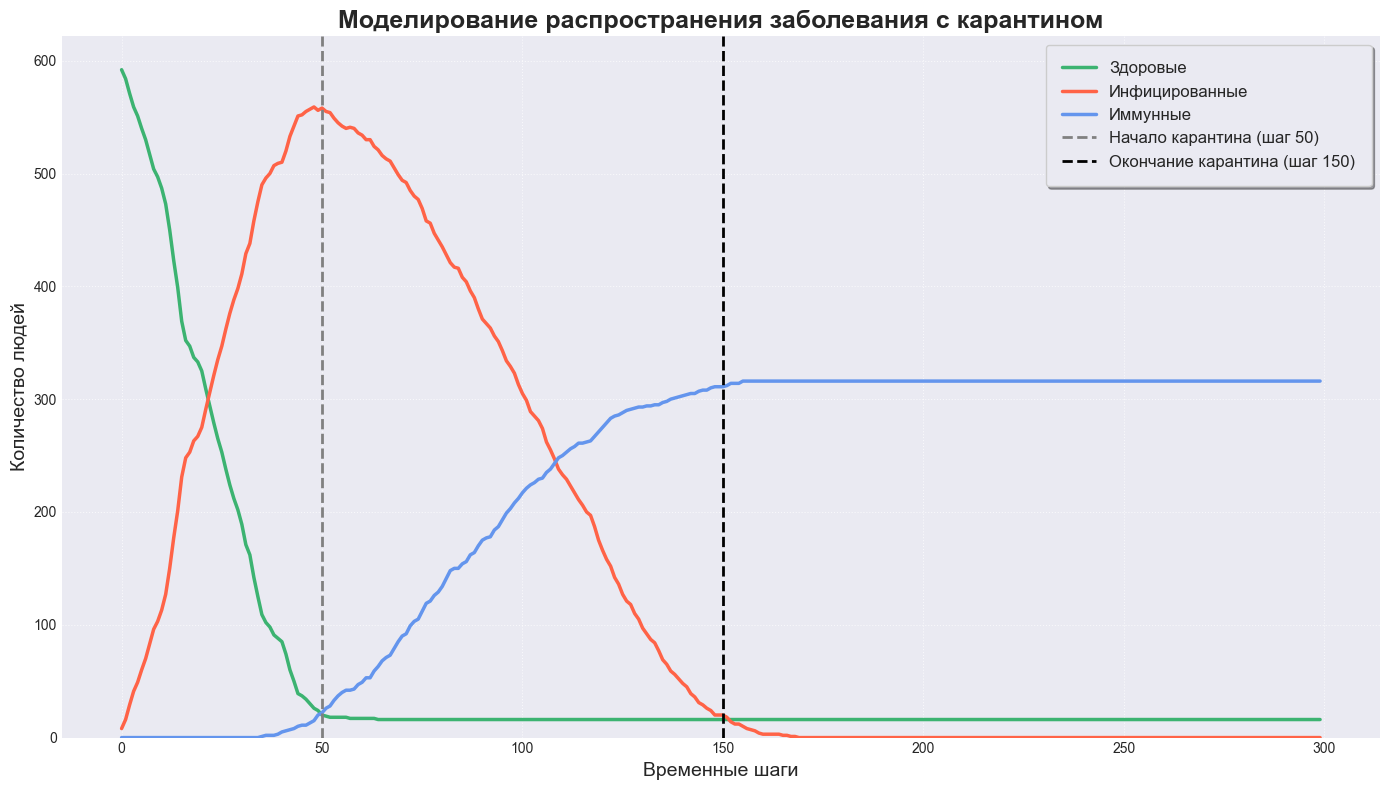

In [11]:
np.random.seed(SEED)
N_ITERS = 300

people = CreateWorld(POPULATION)
LivInfIm = np.zeros((3, N_ITERS), dtype=int)
saved_velocities = None

for step in range(N_ITERS):
    if step == 50:
        saved_velocities = [np.copy(p.v) for p in people]
        for p in people:
            p.v = np.zeros(2)

    if step == 150 and saved_velocities is not None:
        for p, v in zip(people, saved_velocities):
            p.v = v
    
    Iterate()
    CollectData(step)

plotgrafiks_lockdown()


## 3. Моделирование вакцинации

В этом разделе рассматривается сценарий, когда после 30 итераций симуляции становится доступна вакцина. Вакцина обеспечивает мгновенный иммунитет для 90% случайно выбранного населения. Даже если у некоторых людей уже был иммунитет, они все равно получают прививку. Моделирование проводится для 500 агентов и 250 итераций. Графики покажут, как введение вакцины изменяет динамику распространения вируса.

### Логика работы кода:
Код разбит на отдельные блоки для улучшения читаемости и модульности:
-   **Параметры модели**: Константы для сценария с вакцинацией.
-   **Класс `Person`**: Используется тот же класс `Person`.
-   **Функции моделирования**: Используются те же функции моделирования.
-   **Функции визуализации**: Добавлена специальная функция для графиков с отметкой вакцинации.
-   **Основной цикл симуляции**: Реализована логика массовой вакцинации.

### 3.1. Константы модели (для сценария с вакцинацией)

Параметры для сценария вакцинации. `POPULATION` возвращена к 500.

In [12]:
SPACES = 100
VELOCOEF = 5
ASCOEF = 0.1
HEALTH_MID = 100
IMUNOPOWER = 0.8
INI_ILL = 5
POPULATION = 500  # Возвращена популяция к 500
SEED = 42
R_COMM = 5

Inf_count = 0
CollideCount = 0
XLim = SPACES
YLim = SPACES


### 3.2. Класс `Person` (для сценария с вакцинацией)

Используется тот же класс `Person` без изменений.

In [13]:
class Person:
    def __init__(self):
        self.x = np.random.rand(2) * (SPACES - 1)
        self.v = np.random.rand(2) * VELOCOEF + 1
        self.a = np.zeros(2) + ASCOEF
        self.alive = True
        self.immune = False
        self.infected = False
        self.health = np.random.randint(HEALTH_MID - 30, HEALTH_MID + 30)
        self.bottom = np.random.randint(-50, self.health - 30)

    def __str__(self):
        st = ''
        temps = vars(self)
        for item in temps:  st += f'{item}: {temps[item]}\n'
        return st

    def Move(self, V, H, dt=0.1):
        self.x[0] += self.v[0] * dt * np.random.choice([-1, 1]) + 0.5 * self.a[0] * dt * dt
        self.x[1] += self.v[1] * dt + self.a[1] * dt * dt

        if self.x[0] < 0:
            self.x[0] *= -1
            self.v[0] *= -1
        if self.x[0] > H:
            self.x[0] = H - 1
            self.v[0] *= -1
        if self.x[1] < 0:
            self.x[1] *= -1
            self.v[1] *= -1
        if self.x[1] > V:
            self.x[1] = V - 1
            self.v[1] *= -1

    def LowerHealth(self):
        if self.infected and self.health > self.bottom:
            self.health -= 1
        self.alive = (self.health > 0)

    def Cured(self):
        global Inf_count
        if self.infected and self.health <= self.bottom:
            self.infected = False
            Inf_count -= 1
            self.immune = True
            self.bottom -= 5
        if self.immune:
            self.health += np.random.choice([1, 0])

    def Distance(self, you):
        return np.linalg.norm(self.x - you.x)

    def Collide(self, you):
        ypart = you.x[1] - self.x[1]
        xpart = you.x[0] - self.x[0]
        alpha = np.arctan2(ypart, xpart)
        R = np.array(((np.cos(-alpha), -np.sin(-alpha)),
                      (np.sin(-alpha), np.cos(-alpha))))
        vrot = R.dot(self.v)
        wrot = vrot * np.array((1, -1))
        R = np.array(((np.cos(alpha), -np.sin(alpha)),
                      (np.sin(alpha), np.cos(alpha))))
        w = R.dot(wrot)
        self.v = w + 0.05

        if you.infected and not self.immune and self.alive:
            if np.random.rand() > IMUNOPOWER:
                self.infected = True
                self.immune = False


### 3.3. Функции моделирования (для сценария с вакцинацией)

Эти функции также остаются без изменений.

In [14]:
def Iterate():
    global R_COMM, CollideCount, XLim, YLim, people, Inf_count
    Inf_count = 0

    for i, me in enumerate(people):
        if me.alive:
            me.Move(YLim, XLim, dt=0.1) # Изменено: dt приведено к единому значению 0.1
            me.LowerHealth()
            me.Cured()

            for j in range(i + 1, len(people)):
                you = people[j]
                if you.alive and me != you:
                    if me.Distance(you) < R_COMM:
                        CollideCount += 1
                        me.Collide(you)
                        you.Collide(me)
        if me.infected and me.alive:
            Inf_count += 1

def CreateWorld(NPeople=100):
    people = [Person() for _ in range(NPeople)]
    for p in people[:INI_ILL]:
        p.infected = True
    return people

def CollectData(step):
    global LivInfIm, people
    healthy = 0
    infected = 0
    immune = 0

    for person in people:
        if person.alive:
            if person.infected:
                infected += 1
            elif person.immune:
                immune += 1
            else:
                healthy += 1

    LivInfIm[0, step] = healthy
    LivInfIm[1, step] = infected
    LivInfIm[2, step] = immune


### 3.4. Функции визуализации (для сценария с вакцинацией)

Функция `plotgrafiks_vaccination` визуализирует результаты с добавлением вертикальной линии, указывающей на момент проведения вакцинации.

In [15]:
def plotgrafiks_vaccination():
    plt.figure(figsize=(14, 8))
    plt.style.use('seaborn-v0_8-darkgrid')

    plt.plot(LivInfIm[0], label='Здоровые', color='mediumseagreen', linewidth=2.5)
    plt.plot(LivInfIm[1], label='Инфицированные', color='tomato', linewidth=2.5)
    plt.plot(LivInfIm[2], label='Иммунные', color='cornflowerblue', linewidth=2.5)

    plt.axvline(x=30, color='purple', linestyle='-.', linewidth=2, label='Вакцинация (шаг 30)')

    plt.title('Моделирование распространения заболевания с вакцинацией', fontsize=18, fontweight='bold')
    plt.xlabel('Временные шаги', fontsize=14)
    plt.ylabel('Количество людей', fontsize=14)
    plt.legend(fontsize=12, frameon=True, shadow=True, borderpad=1)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()


### 3.5. Основной цикл симуляции (Сценарий с вакцинацией)

Этот блок выполняет симуляцию, включая логику массовой вакцинации на определенном временном шаге.

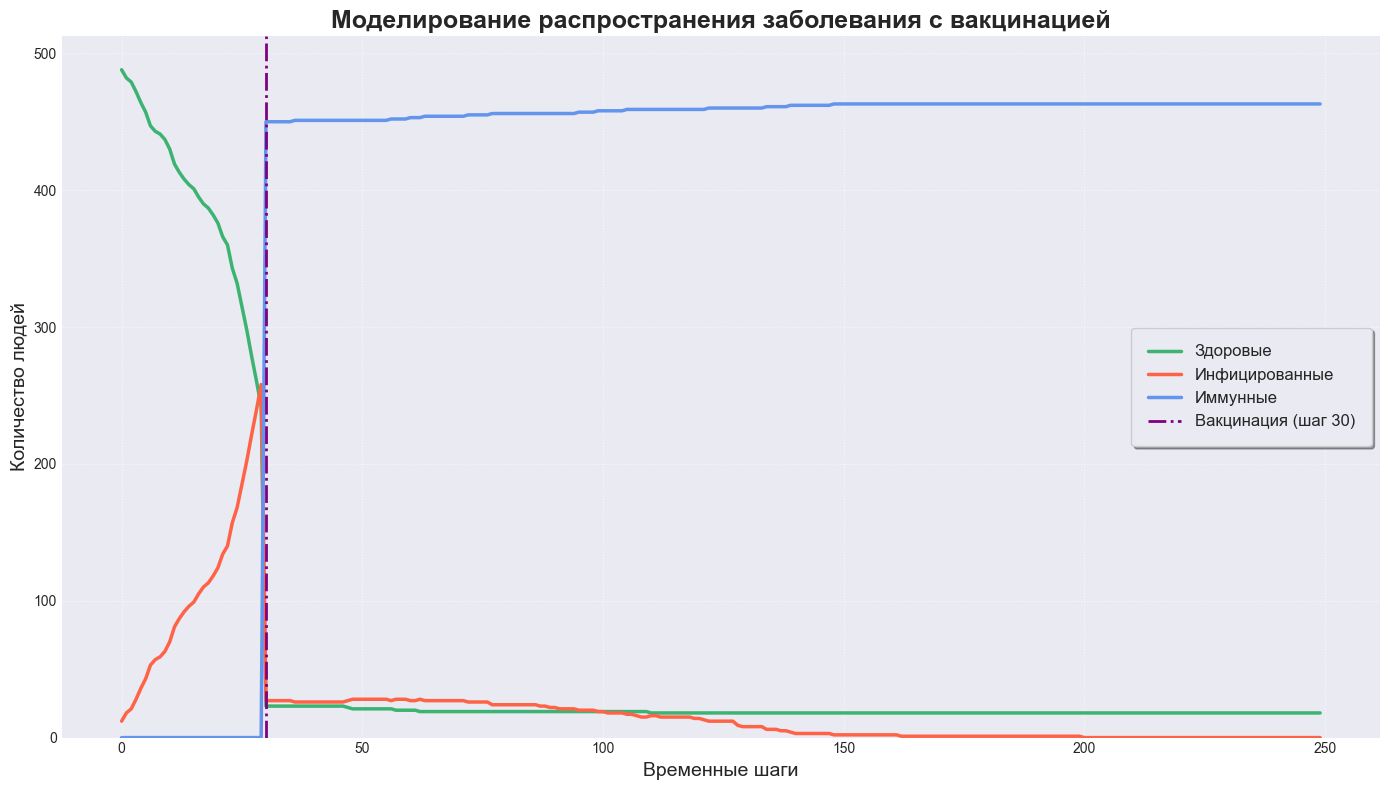

In [16]:
np.random.seed(SEED)
N_ITERS = 250

people = CreateWorld(POPULATION)
LivInfIm = np.zeros((3, N_ITERS), dtype=int)

for step in range(N_ITERS):
    Iterate()
    if step == 30:
        vaccinated_count = int(0.9 * POPULATION)
        indices = np.arange(len(people))
        np.random.shuffle(indices)
        
        vaccinated_indices = indices[:vaccinated_count]
        
        for idx in vaccinated_indices:
            person = people[idx]
            if person.alive:
                person.immune = True
                if person.infected:
                    person.infected = False
                    Inf_count -= 1
    CollectData(step)

plotgrafiks_vaccination()


## 4. Моделирование распространения вируса в ограниченной области (высокая плотность)

В этом разделе мы исследуем, как плотность населения влияет на распространение заболевания. Модель запускается с 300 агентами на ограниченной территории размером 150x150 единиц и длится 200 итераций. Ограниченное пространство увеличивает частоту контактов между агентами, что может повлиять на скорость распространения вируса.

### Логика работы кода:
Код разбит на отдельные блоки для улучшения читаемости и модульности:
-   **Параметры модели**: Обновленные константы, включая размер пространства и начальное количество инфицированных.
-   **Класс `Person`**: Используется тот же класс `Person`.
-   **Функции моделирования**: Используются те же функции моделирования с небольшим улучшением в подсчете `Inf_count`.
-   **Функции визуализации**: Адаптированная функция для графиков с указанием параметров плотности.
-   **Основной цикл симуляции**: Запускает симуляцию в условиях ограниченного пространства.

### 4.1. Константы модели (для сценария с ограниченной областью)

В этом сценарии `SPACES` (размер пространства) увеличен для создания более плотной среды, а `INI_ILL` также увеличено для демонстрации начального распространения в этих условиях.

In [17]:
SPACES = 150      # Увеличен размер пространства для демонстрации плотности
VELOCOEF = 5
ASCOEF = 0.1
HEALTH_MID = 100
IMUNOPOWER = 0.8
INI_ILL = 15      # Увеличено начальное количество инфицированных
POPULATION = 300  # Общее количество агентов
SEED = 42
R_COMM = 5

Inf_count = 0
CollideCount = 0
XLim = SPACES
YLim = SPACES


### 4.2. Класс `Person` (для сценария с ограниченной областью)

Используется тот же класс `Person` без изменений.

In [18]:
class Person:
    def __init__(self):
        self.x = np.random.rand(2) * (SPACES - 1)
        self.v = np.random.rand(2) * VELOCOEF + 1
        self.a = np.zeros(2) + ASCOEF
        self.alive = True
        self.immune = False
        self.infected = False
        self.health = np.random.randint(HEALTH_MID - 30, HEALTH_MID + 30)
        self.bottom = np.random.randint(-50, self.health - 30)

    def __str__(self):
        st = ''
        temps = vars(self)
        for item in temps:  st += f'{item}: {temps[item]}\n'
        return st

    def Move(self, V, H, dt=0.1):
        self.x[0] += self.v[0] * dt * np.random.choice([-1, 1]) + 0.5 * self.a[0] * dt * dt
        self.x[1] += self.v[1] * dt + self.a[1] * dt * dt

        if self.x[0] < 0:
            self.x[0] *= -1
            self.v[0] *= -1
        if self.x[0] > H:
            self.x[0] = H - 1
            self.v[0] *= -1
        if self.x[1] < 0:
            self.x[1] *= -1
            self.v[1] *= -1
        if self.x[1] > V:
            self.x[1] = V - 1
            self.v[1] *= -1

    def LowerHealth(self):
        if self.infected and self.health > self.bottom:
            self.health -= 1
        self.alive = (self.health > 0)

    def Cured(self):
        global Inf_count
        if self.infected and self.health <= self.bottom:
            self.infected = False
            Inf_count -= 1
            self.immune = True
            self.bottom -= 5
        if self.immune:
            self.health += np.random.choice([1, 0])

    def Distance(self, you):
        return np.linalg.norm(self.x - you.x)

    def Collide(self, you):
        ypart = you.x[1] - self.x[1]
        xpart = you.x[0] - self.x[0]
        alpha = np.arctan2(ypart, xpart)
        R = np.array(((np.cos(-alpha), -np.sin(-alpha)),
                      (np.sin(-alpha), np.cos(-alpha))))
        vrot = R.dot(self.v)
        wrot = vrot * np.array((1, -1))
        R = np.array(((np.cos(alpha), -np.sin(alpha)),
                      (np.sin(alpha), np.cos(alpha))))
        w = R.dot(wrot)
        self.v = w + 0.05

        if you.infected and not self.immune and self.alive:
            if np.random.rand() > IMUNOPOWER:
                self.infected = True
                self.immune = False


### 4.3. Функции моделирования (для сценария с ограниченной областью)

Эти функции используются для управления логикой симуляции.

In [19]:
def Iterate():
    global R_COMM, CollideCount, XLim, YLim, people, Inf_count
    Inf_count = 0  # Сбрасываем счетчик инфицированных в начале каждой итерации

    for i, me in enumerate(people):
        if me.alive:
            me.Move(YLim, XLim, dt=0.1) # Изменено: dt приведено к единому значению 0.1
            me.LowerHealth()
            me.Cured()

            for j in range(i + 1, len(people)): # Оптимизированный цикл для избежания повторных проверок
                you = people[j]
                if you.alive and me != you:
                    if me.Distance(you) < R_COMM:
                        CollideCount += 1
                        me.Collide(you)
                        you.Collide(me)
        if me.infected and me.alive:
            Inf_count += 1

def CreateWorld(NPeople=300):
    people = [Person() for _ in range(NPeople)]
    for p in people[:INI_ILL]:
        p.infected = True
    return people

def CollectData(step):
    global LivInfIm, people
    healthy = 0
    infected = 0
    immune = 0

    for person in people:
        if person.alive:
            if person.infected:
                infected += 1
            elif person.immune:
                immune += 1
            else:
                healthy += 1

    LivInfIm[0, step] = healthy
    LivInfIm[1, step] = infected
    LivInfIm[2, step] = immune


### 4.4. Функции визуализации (для сценария с ограниченной областью)

Функция `plotgrafiks_density` отображает динамику заболевания с учетом параметров плотности.

In [20]:
def plotgrafiks_density():
    plt.figure(figsize=(14, 8))
    plt.style.use('seaborn-v0_8-darkgrid')

    plt.plot(LivInfIm[0], label='Здоровые', color='mediumseagreen', linewidth=2.5)
    plt.plot(LivInfIm[1], label='Инфицированные', color='tomato', linewidth=2.5)
    plt.plot(LivInfIm[2], label='Иммунные', color='cornflowerblue', linewidth=2.5)

    plt.title(f'Моделирование распространения заболевания в ограниченной области\n(Популяция: {POPULATION}, Область: {SPACES}x{SPACES}, Итерации: {N_ITERS})', fontsize=18, fontweight='bold')
    plt.xlabel('Временные шаги', fontsize=14)
    plt.ylabel('Количество людей', fontsize=14)
    plt.legend(fontsize=12, frameon=True, shadow=True, borderpad=1)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.ylim(bottom=0)
    plt.tight_layout()
    plt.show()


### 4.5. Основной цикл симуляции (Сценарий с ограниченной областью)

Этот блок выполняет симуляцию в условиях ограниченного пространства, демонстрируя влияние плотности на распространение вируса.

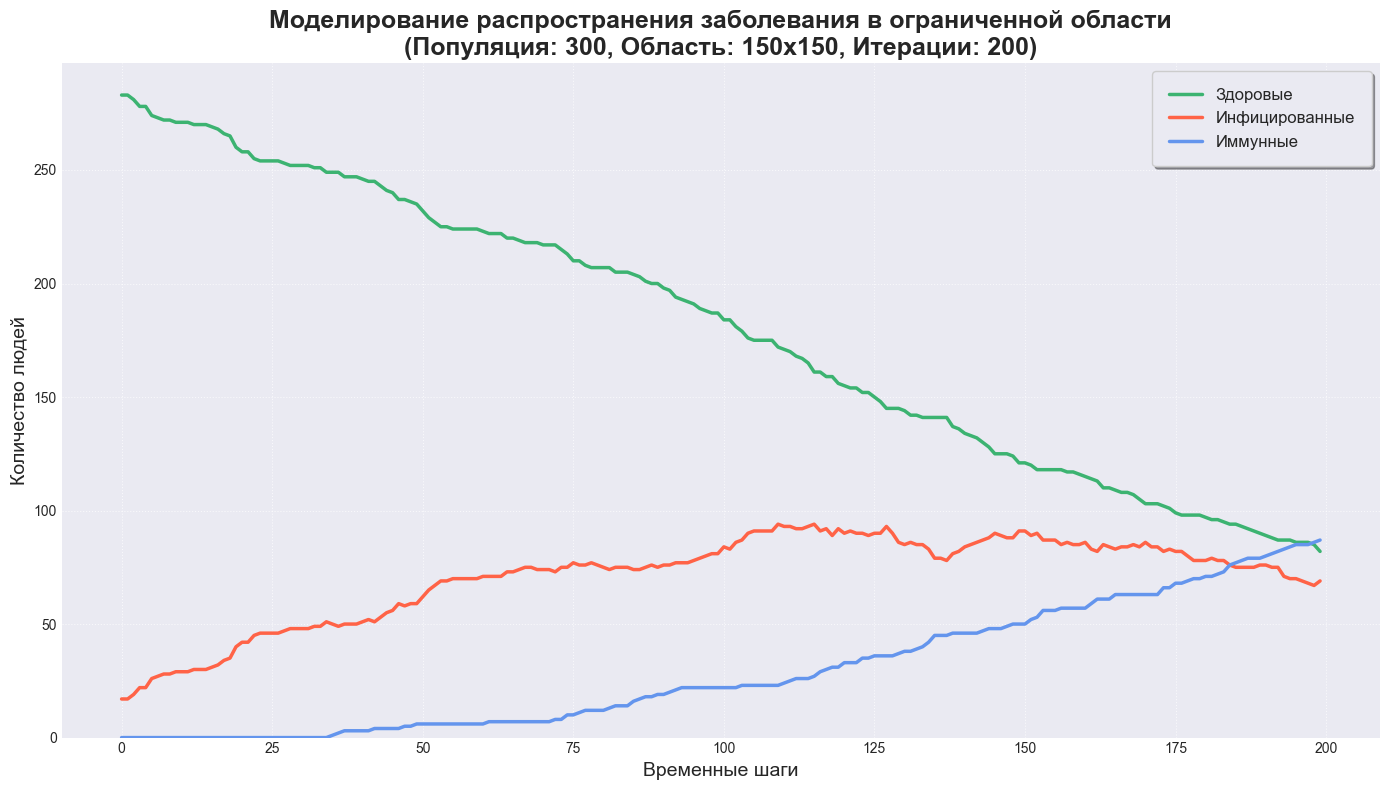

In [21]:
np.random.seed(SEED)
N_ITERS = 200

people = CreateWorld(POPULATION)
LivInfIm = np.zeros((3, N_ITERS), dtype=int)

for step in range(N_ITERS):
    Iterate()
    CollectData(step)

plotgrafiks_density()
